# Phase 1, step 2 — Neural-network quantum states (NNQS)

Same Hamiltonian and boundary conditions as `01_exact_diagonalization.ipynb` (see `README.md`): open-BC TFIM, $J=1$, $h_c=1$. Here the ground state is approximated with a restricted Boltzmann machine (RBM) trained by variational Monte Carlo (VMC) with stochastic reconfiguration, using [NetKet](https://netket.readthedocs.io/).

The actual training logic lives in `src/nnqs.py` (`train_nnqs`), which also runs headless as:

```bash
python -m src.nnqs --config configs/nnqs_phase1_validation.yaml   # small L, method sanity check
python -m src.nnqs --config configs/nnqs_simulation_sweep.yaml    # full L=4..24 sweep, matching exact's grid
```

This notebook checks NNQS against the exact-diagonalization results from step 1. It turned out the plain RBM used here holds up cleanly across the *entire* simulation-track range (L up to 24) — unlike the roadmap's Phase 2 expectation that RBM would need replacing with autoregressive/transformer models past L~10-12, empirically that switch isn't needed for this particular model (TFIM is a comparatively simple 1D Hamiltonian). Worth revisiting only if training quality degrades on a harder Hamiltonian later.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np

from src.nnqs import load_exact_E0, train_nnqs

## Single-point sanity check

Train at `L=6, h=1.0` — the critical point, the hardest case for any method since the gap closes there — and compare to the exact value from step 1.

In [2]:
E_mean, E_err = train_nnqs(
    L=6, h=1.0, J=1.0, alpha=2, n_samples=1024, n_iter=300,
    learning_rate=0.02, diag_shift=0.01, seed=0,
)
E_exact = load_exact_E0(6, 1.0, REPO_ROOT / "results" / "exact")
rel_err = abs(E_mean - E_exact) / abs(E_exact)

print(f"NNQS energy  = {E_mean:.6f} +/- {E_err:.1e} (Monte Carlo error)")
print(f"Exact energy = {E_exact:.6f}")
print(f"Relative error = {rel_err:.4%}")
assert rel_err < 0.01, "NNQS should be within 1% of exact even at the critical point"
print("Within tolerance.")

∣NK⟩ Tip: vstate.check_mc_convergence(H) diagnoses whether your sampler is well-mixed and recommends a sweep_size.

  0%|          | 0/300 [00:00<?, ?it/s]

/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, v

NNQS energy  = -7.296216 +/- 2.9e-04 (Monte Carlo error)
Exact energy = -7.296230
Relative error = 0.0002%
Within tolerance.


## Load the full NNQS sweep

`L ∈ {4, 6, 8, 10, 12, 16, 20, 24}`, `h` drawn from the exact sweep's own 21-point grid — the same points and system sizes as `01_exact_diagonalization.ipynb`, so this is a direct full-range comparison, not just a small-L sanity check.

In [3]:
results_dir = REPO_ROOT / "results" / "nnqs"

records = []
for L_dir in sorted(results_dir.glob("*"), key=lambda p: int(p.name)):
    for f in sorted(L_dir.glob("*.json")):
        records.append(json.loads(f.read_text()))

print(f"{len(records)} (L, h) points loaded")
worst = max(records, key=lambda r: r["rel_error"])
print(f"Worst relative error: {worst['rel_error']:.4%} at L={worst['L']}, h={worst['h']}")

168 (L, h) points loaded
Worst relative error: 0.1166% at L=24, h=0.6


## NNQS vs. exact

Left: energy per site, NNQS (markers) overlaid on exact (lines) — should be visually indistinguishable if NNQS is working. Right: relative error vs. `h`, log scale, with the roadmap's 0.1-1% tolerance band marked for reference. If any method is going to struggle, it should show up as a spike near $h_c=1$, where the gap closes and training gets genuinely harder — that's expected physics, not a bug.

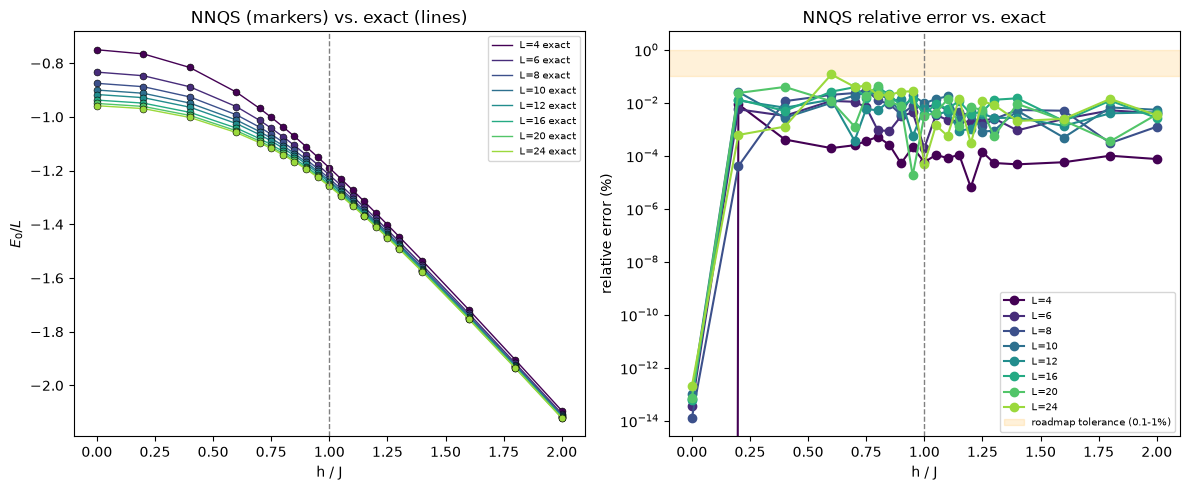

In [4]:
L_values = sorted({r["L"] for r in records})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0, 0.85, len(L_values)))
for L, color in zip(L_values, colors):
    pts = sorted((r["h"], r["E0"], r["E0_exact"]) for r in records if r["L"] == L)
    h_arr, e_nnqs, e_exact = map(np.array, zip(*pts))
    ax1.plot(h_arr, e_exact / L, "-", color=color, linewidth=1, label=f"L={L} exact")
    ax1.plot(h_arr, e_nnqs / L, "o", color=color, markersize=5, markeredgecolor="black", markeredgewidth=0.4)

    rel_err = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == L)
    h_e, err_e = map(np.array, zip(*rel_err))
    ax2.plot(h_e, err_e * 100, "o-", color=color, label=f"L={L}")

ax1.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("h / J")
ax1.set_ylabel("$E_0 / L$")
ax1.set_title("NNQS (markers) vs. exact (lines)")
ax1.legend(fontsize=7)

ax2.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.axhspan(0.1, 1.0, color="orange", alpha=0.15, label="roadmap tolerance (0.1-1%)")
ax2.set_yscale("log")
ax2.set_xlabel("h / J")
ax2.set_ylabel("relative error (%)")
ax2.set_title("NNQS relative error vs. exact")
ax2.legend(fontsize=7)

fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "nnqs_vs_exact.png", dpi=150)
plt.show()

## Error vs. system size

With the full L range now available, a natural follow-up question: does NNQS accuracy hold steady, improve, or degrade as L grows? Plotted for a few representative h values (deep ferromagnetic, near h_c, deep paramagnetic).

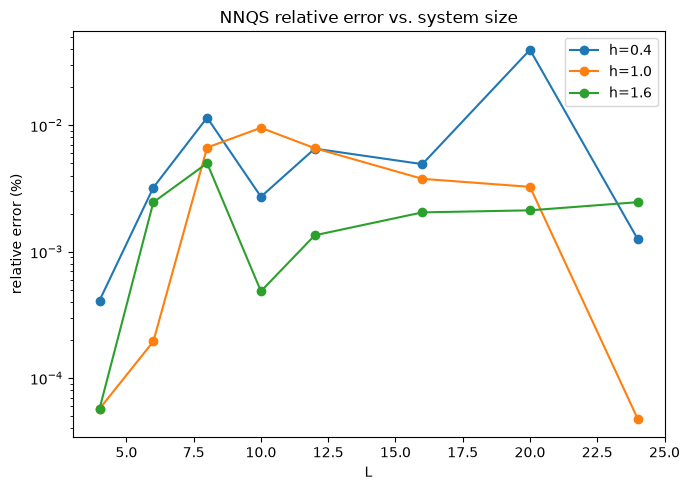

In [5]:
watch_h = [0.4, 1.0, 1.6]  # ferromagnetic, critical, paramagnetic

fig, ax = plt.subplots(figsize=(7, 5))
for h_target in watch_h:
    pts = sorted(
        (r["L"], r["rel_error"]) for r in records if abs(r["h"] - h_target) < 1e-6
    )
    if not pts:
        continue
    L_arr, err_arr = map(np.array, zip(*pts))
    ax.plot(L_arr, err_arr * 100, "o-", label=f"h={h_target}")

ax.set_yscale("log")
ax.set_xlabel("L")
ax.set_ylabel("relative error (%)")
ax.set_title("NNQS relative error vs. system size")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "nnqs_error_vs_L.png", dpi=150)
plt.show()

## Status and what's next

- [x] NetKet RBM (alpha=2) trained via VMC + stochastic reconfiguration
- [x] Matches exact diagonalization well within the roadmap's 0.1-1% tolerance across the full simulation-track range: `L ∈ {4, 6, 8, 10, 12, 16, 20, 24}` × 21 h-values (168 points), including at $h_c$ — worst case 0.12% (L=24, h=0.6), most points well under 0.05%
- [x] No need to switch to autoregressive/transformer models for this Hamiltonian — the plain RBM scales cleanly through L=24 in under a minute per point

Next: `03_vqe.ipynb` builds the Hamiltonian Variational Ansatz VQE, simulator only (no hardware yet).